# Dijkstra's Algorithm — Shortest Path (Non-Negative Weights)

Finds the shortest path from a single source node to all other nodes in a
weighted graph, provided **no edge has a negative weight**.

Uses a min-priority queue (we'll reuse the Min-Heap concept from Task 1 —
here using Python's built-in `heapq` for simplicity, since the algorithm
itself is the focus here, not heap re-implementation) to always expand the
closest unvisited node next — a greedy approach that works correctly only
because weights are non-negative.

- Time complexity: O((V + E) log V) with a binary heap
- Space complexity: O(V + E)

In [1]:
class Graph:
    def __init__(self):
        self.adj = {}

    def add_node(self, node):
        if node not in self.adj:
            self.adj[node] = []

    def add_edge(self, u, v, weight):
        self.add_node(u)
        self.add_node(v)
        self.adj[u].append((v, weight))

    def nodes(self):
        return list(self.adj.keys())

    def edges(self):
        result = []
        for u in self.adj:
            for v, w in self.adj[u]:
                result.append((u, v, w))
        return result

    def neighbors(self, u):
        return self.adj.get(u, [])

    def num_nodes(self):
        return len(self.adj)

    def num_edges(self):
        return sum(len(v) for v in self.adj.values())

    def __repr__(self):
        lines = []
        for u in self.adj:
            for v, w in self.adj[u]:
                lines.append(f"  {u} -> {v}  (weight={w})")
        return f"Graph({self.num_nodes()} nodes, {self.num_edges()} edges)\n" + "\n".join(lines)

In [2]:
import heapq

def dijkstra(graph: Graph, source, track_steps=False):
    """
    Returns (distances, predecessors) — shortest distance from source to every
    reachable node, and the predecessor of each node on its shortest path
    (used to reconstruct the actual path).

    If track_steps=True, also returns a list of step snapshots for visualization:
    each step records which node was just finalized and the current distance table.
    """
    distances = {node: float('inf') for node in graph.nodes()}
    predecessors = {node: None for node in graph.nodes()}
    distances[source] = 0

    visited = set()
    pq = [(0, source)]  # (distance, node)
    steps = []

    while pq:
        dist_u, u = heapq.heappop(pq)

        if u in visited:
            continue
        visited.add(u)

        if track_steps:
            steps.append({
                "finalized_node": u,
                "distances": distances.copy(),
                "visited": visited.copy()
            })

        for v, weight in graph.neighbors(u):
            if weight < 0:
                raise ValueError(f"Dijkstra's algorithm cannot handle negative edge weight: {u}->{v} = {weight}")
            new_dist = dist_u + weight
            if new_dist < distances[v]:
                distances[v] = new_dist
                predecessors[v] = u
                heapq.heappush(pq, (new_dist, v))

    if track_steps:
        return distances, predecessors, steps
    return distances, predecessors


def reconstruct_path(predecessors, source, target):
    """Rebuilds the shortest path from source to target using the predecessor map."""
    if predecessors.get(target) is None and target != source:
        return None  # unreachable
    path = []
    node = target
    while node is not None:
        path.append(node)
        node = predecessors[node]
    path.reverse()
    return path if path[0] == source else None

## Sanity Test

In [3]:
g = Graph()
edges = [
    ("Kathmandu", "Bhaktapur", 25),
    ("Kathmandu", "Lalitpur", 15),
    ("Lalitpur", "Bhaktapur", 20),
    ("Bhaktapur", "Dhulikhel", 30),
    ("Lalitpur", "Dhulikhel", 45),
    ("Dhulikhel", "Nagarkot", 35),
    ("Kathmandu", "Nagarkot", 60),
    ("Nagarkot", "Bhaktapur", 28),
]
for u, v, w in edges:
    g.add_edge(u, v, w)

distances, predecessors = dijkstra(g, "Kathmandu")

print("Shortest distances from Kathmandu:")
for node, dist in distances.items():
    print(f"  {node}: {dist}")

print("\nShortest path to Nagarkot:", reconstruct_path(predecessors, "Kathmandu", "Nagarkot"))
print("Shortest path to Dhulikhel:", reconstruct_path(predecessors, "Kathmandu", "Dhulikhel"))

Shortest distances from Kathmandu:
  Kathmandu: 0
  Bhaktapur: 25
  Lalitpur: 15
  Dhulikhel: 55
  Nagarkot: 60

Shortest path to Nagarkot: ['Kathmandu', 'Nagarkot']
Shortest path to Dhulikhel: ['Kathmandu', 'Bhaktapur', 'Dhulikhel']


## Visualizing the Shortest Path Tree

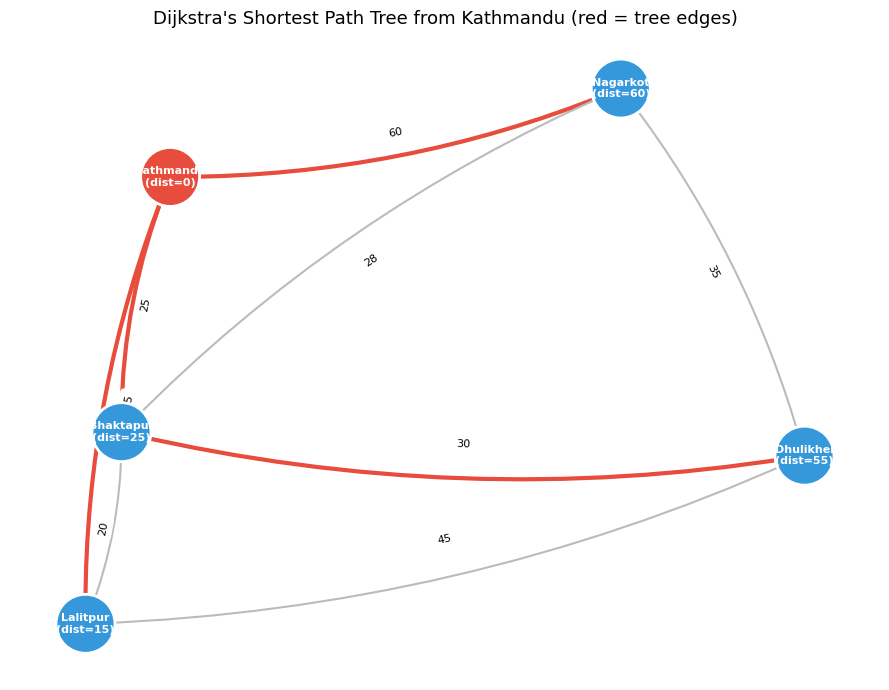

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(graph, title="Graph", highlight_edges=None, highlight_nodes=None, node_labels=None):
    G = nx.DiGraph()
    for u, v, w in graph.edges():
        G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42, k=1.2)
    plt.figure(figsize=(9, 7))

    highlight_edges = highlight_edges or set()
    highlight_nodes = highlight_nodes or set()

    edge_colors = ['#e74c3c' if (u, v) in highlight_edges else '#bbbbbb' for u, v in G.edges()]
    edge_widths = [3 if (u, v) in highlight_edges else 1.5 for u, v in G.edges()]
    node_colors = ['#e74c3c' if n in highlight_nodes else '#3498db' for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, edgecolors='white', linewidths=2)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                            arrowsize=20, connectionstyle='arc3,rad=0.1')

    labels = {}
    for n in G.nodes():
        text = n
        if node_labels and n in node_labels:
            text += f"\n({node_labels[n]})"
        labels[n] = text
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold', font_color='white')

    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Build the shortest-path-tree edges (from each node back to its predecessor)
sp_edges = set()
for node, pred in predecessors.items():
    if pred is not None:
        sp_edges.add((pred, node))

draw_graph(g, title="Dijkstra's Shortest Path Tree from Kathmandu (red = tree edges)",
           highlight_edges=sp_edges, highlight_nodes={"Kathmandu"},
           node_labels={n: f"dist={d}" for n, d in distances.items()})

## Step-by-Step Execution Visualization

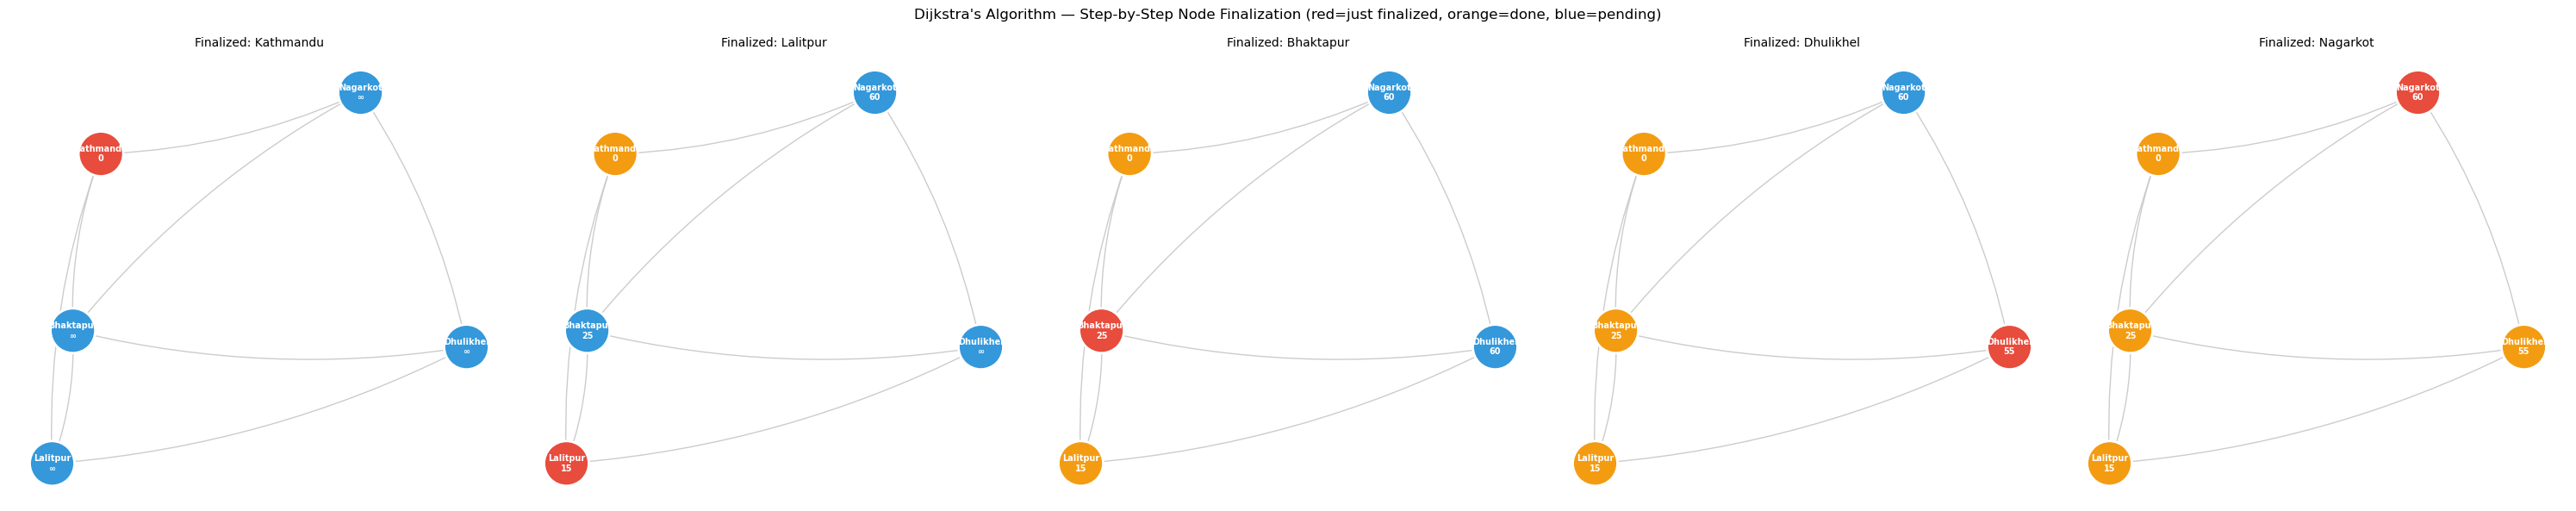

In [5]:
distances2, predecessors2, steps = dijkstra(g, "Kathmandu", track_steps=True)

fig, axes = plt.subplots(1, len(steps), figsize=(6 * len(steps), 6))
if len(steps) == 1:
    axes = [axes]

G = nx.DiGraph()
for u, v, w in g.edges():
    G.add_edge(u, v, weight=w)
pos = nx.spring_layout(G, seed=42, k=1.2)

for ax, step in zip(axes, steps):
    visited = step["visited"]
    dists = step["distances"]

    node_colors = []
    for n in G.nodes():
        if n == step["finalized_node"]:
            node_colors.append('#e74c3c')       # just finalized this step
        elif n in visited:
            node_colors.append('#f39c12')        # already finalized earlier
        else:
            node_colors.append('#3498db')        # not yet visited

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1400,
                            edgecolors='white', linewidths=2)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#cccccc', arrowsize=15,
                            connectionstyle='arc3,rad=0.1')

    labels = {n: f"{n}\n{dists[n] if dists[n] != float('inf') else '∞'}" for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7, font_weight='bold', font_color='white')

    ax.set_title(f"Finalized: {step['finalized_node']}", fontsize=10)
    ax.axis('off')

plt.suptitle("Dijkstra's Algorithm — Step-by-Step Node Finalization (red=just finalized, orange=done, blue=pending)", fontsize=12)
plt.tight_layout()
plt.show()